# Chi-square on different data: penguin species & island

*Part 2 · Lesson 17 · another dataset  ·  data: Palmer Penguins*

*↩ A companion to [Lesson 17: Chi-square: goodness-of-fit & independence](17-chi-square.ipynb).*

**↩ Back:** [Lesson 17: Chi-square: goodness-of-fit & independence](17-chi-square.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](17-chi-square~the-code.ipynb)

In the core lesson we met the **chi-square test** ($\chi^2$, the Greek letter "kai") on the Titanic,
where the link between, say, sex and survival was clear but **moderate** — independence was plausibly
worth testing. Here we run the very same machinery on a wildly different table, and meet the **opposite
extreme**: an association so near-total that knowing one variable can make the other *certain* — or
*impossible*.

Our data is the **Palmer Penguins** — 344 birds, each tagged with its **species** (Adelie, Chinstrap,
Gentoo) and the **island** it was found on (Biscoe, Dream, Torgersen). We'll cross-tabulate species
against island, ask whether the two are **independent**, and watch the test detonate. Same recipe as the
core — observed vs expected counts, the statistic $\sum (O-E)^2/E$, degrees of freedom, the p-value — but
a far more dramatic verdict. Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

PENGUINS_URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
# Keep only rows where BOTH columns we need are present.
pen = sl.load_csv('penguins.csv', url=PENGUINS_URL).dropna(subset=['species', 'island'])

print(f'{len(pen)} penguins (rows with species AND island recorded)')
print('Species:', sorted(pen['species'].unique()))
print('Islands:', sorted(pen['island'].unique()))
pen[['species', 'island', 'body_mass_g']].head()

344 penguins (rows with species AND island recorded)
Species: ['Adelie', 'Chinstrap', 'Gentoo']
Islands: ['Biscoe', 'Dream', 'Torgersen']


,species,island,body_mass_g
0,Adelie,Torgersen,3750.0
1,Adelie,Torgersen,3800.0
2,Adelie,Torgersen,3250.0
3,Adelie,Torgersen,NaN
4,Adelie,Torgersen,3450.0


## 1) The same recipe — observed vs expected counts

Chi-square never changes its one move, whatever the data:

1. Count what actually happened — the **observed** counts $O$.
2. Work out what we'd expect *if our hypothesis were true* — the **expected** counts $E$.
3. Measure the total gap with a single number, the **chi-square statistic**:

$$\chi^2 \;=\; \sum_{\text{cells}} \frac{(O - E)^2}{E}.$$

- **The math:** for each cell, take the gap between observed and expected, **square** it (so over- and
  under-shoots both count), and **divide by the expected count** (so a miss of 10 stings more when only 5
  were expected than when 500 were). Add up every piece.
- **The meaning:** $\chi^2$ is a *total surprise score*. If the data matches the hypothesis, every
  $O \approx E$, the pieces are tiny, and $\chi^2$ is near 0. The wider the mismatches, the bigger it grows.
- **The interpretation:** a big $\chi^2$ is evidence the hypothesis is wrong — judged against the
  **p-value**, the probability of a gap that large purely by chance.

Here's the same tiny function the core lesson used.

In [2]:
def chi_square_stat(observed, expected):
    # Sum over cells of (O - E)^2 / E.
    observed = np.asarray(observed, dtype=float)
    expected = np.asarray(expected, dtype=float)
    return np.sum((observed - expected) ** 2 / expected)

# Sanity check: if observed exactly equals expected, surprise = 0.
print('chi^2 when O == E :', chi_square_stat([10, 20, 30], [10, 20, 30]))
print('chi^2 when O != E :', chi_square_stat([5, 25, 30], [10, 20, 30]))

chi^2 when O == E : 0.0
chi^2 when O != E : 3.75


## 2) The contingency table — species against island

For a test of **independence** we cross-tabulate the two categorical variables into a **contingency
table**: a grid whose cells count how many penguins fall into each species/island combination.

In [3]:
contingency = pd.crosstab(pen['species'], pen['island'])
print('OBSERVED counts (species x island):\n')
print(contingency)

row_totals = contingency.sum(axis=1)   # penguins per species
col_totals = contingency.sum(axis=0)   # penguins per island
print('\nRow totals (by species):', dict(row_totals))
print('Column totals (by island):', dict(col_totals))
print(f'Grand total: {contingency.values.sum()}')

OBSERVED counts (species x island):

island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0

Row totals (by species): {'Adelie': np.int64(152), 'Chinstrap': np.int64(68), 'Gentoo': np.int64(124)}
Column totals (by island): {'Biscoe': np.int64(168), 'Dream': np.int64(124), 'Torgersen': np.int64(52)}
Grand total: 344


Look hard at that table, because it is the whole story:

| | Biscoe | Dream | Torgersen |
|---|---|---|---|
| **Adelie** | some | some | some |
| **Chinstrap** | **0** | all | **0** |
| **Gentoo** | all | **0** | **0** |

Those **zeros are structural**, not accidents of a small sample. **Chinstrap** penguins were found
**only on Dream**; **Gentoo** penguins **only on Biscoe**; only **Adelie** turns up on all three islands.
So if I tell you a penguin lives on Torgersen, it is *certainly* an Adelie — and *certainly not* a
Chinstrap or Gentoo. Knowing the island can pin the species down completely. That is about as far from
"the two have nothing to do with each other" as a table can get. Let's make independence predict against
it.

## 3) What would "no relationship" predict?

The null hypothesis is **independence**: a penguin's species has *nothing* to do with its island. If that
were true, every island would draw from the *same* species mix — the overall mix — and the **expected**
count for any cell would be

$$E_{ij} = \frac{(\text{row } i \text{ total}) \times (\text{column } j \text{ total})}{\text{grand total}}.$$

**Why this formula?** Under independence, $P(\text{species }i \text{ and island } j) = P(\text{species } i)
\times P(\text{island } j)$. Multiply that joint probability by the grand total $N$ and the $N$'s collapse
into exactly row-total times column-total over $N$. It's just "expected count = probability × N" with the
independence assumption baked in. Crucially, this formula **never produces a zero** when both totals are
positive — so it will confidently predict penguins in cells where we observed *none*.

In [4]:
N = contingency.values.sum()
expected = np.outer(row_totals, col_totals) / N
expected_df = pd.DataFrame(expected.round(1), index=contingency.index, columns=contingency.columns)

print('EXPECTED counts IF species were independent of island:\n')
print(expected_df)
print('\nOBSERVED counts (what actually happened):\n')
print(contingency)

EXPECTED counts IF species were independent of island:

island     Biscoe  Dream  Torgersen
species                            
Adelie       74.2   54.8       23.0
Chinstrap    33.2   24.5       10.3
Gentoo       60.6   44.7       18.7

OBSERVED counts (what actually happened):

island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0


Set the two tables side by side and the engine of the test jumps out. Where we **observed 0** Chinstraps
on Biscoe, independence cheerfully **expects about 33**. Where we observed 0 Gentoos on Dream, it expects
about 45. Those aren't rounding wobbles — independence predicts *dozens* of penguins in cells the real
world left empty, because it has no way to know a species can be flat-out absent from an island. Every one
of those gaps is a big $(O-E)$, and after squaring and dividing by $E$ they pile up into a huge total.
That pile-up is exactly what we compute next.

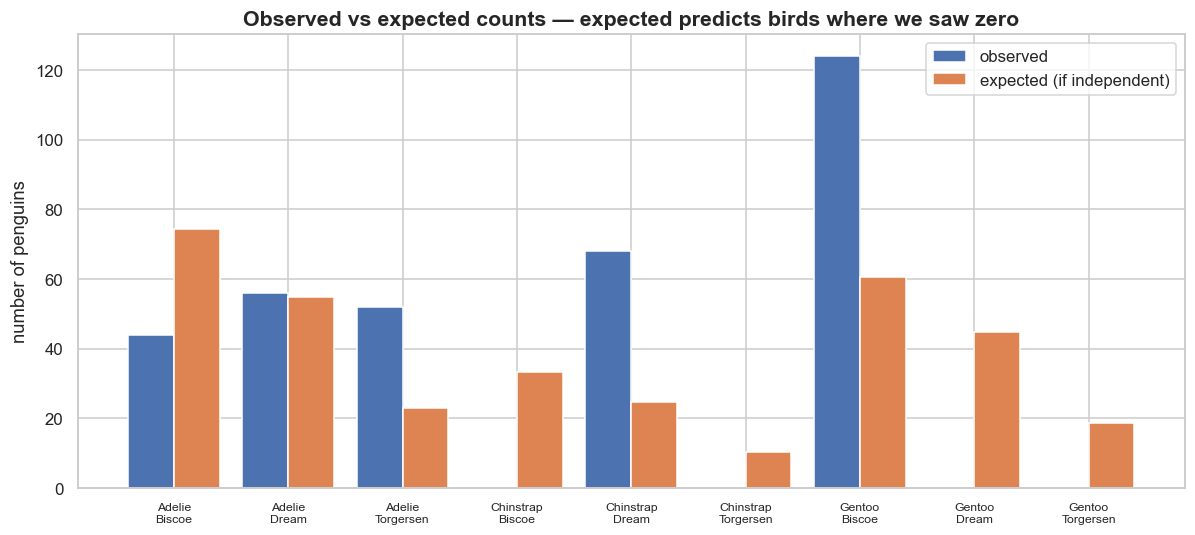

Orange bars stand tall over empty blue ones: every such gap inflates chi^2.


In [5]:
# Side-by-side as a grouped bar chart, one cluster per (species, island) cell.
labels = [f'{sp}\n{isl}' for sp in contingency.index for isl in contingency.columns]
obs_flat = contingency.values.flatten()
exp_flat = expected.flatten()

x = np.arange(len(labels)); w = 0.4
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, obs_flat, width=w, color='#4c72b0', label='observed')
ax.bar(x + w/2, exp_flat, width=w, color='#dd8452', label='expected (if independent)')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('number of penguins')
ax.set_title('Observed vs expected counts — expected predicts birds where we saw zero')
ax.legend(); plt.tight_layout(); plt.show()
print('Orange bars stand tall over empty blue ones: every such gap inflates chi^2.')

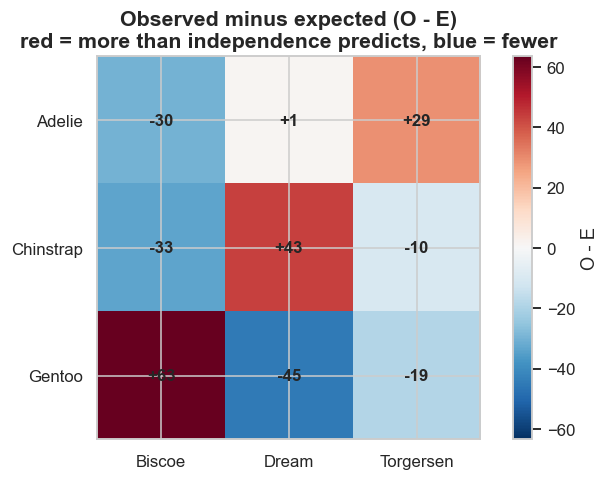

In [6]:
# A heatmap of the gap (O - E) shows where the surprise lives.
diff = contingency.values - expected
fig, ax = plt.subplots(figsize=(6.5, 4.5))
vmax = np.abs(diff).max()
im = ax.imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(contingency.columns))); ax.set_xticklabels(contingency.columns)
ax.set_yticks(range(len(contingency.index)));   ax.set_yticklabels(contingency.index)
for i in range(diff.shape[0]):
    for j in range(diff.shape[1]):
        ax.text(j, i, f'{diff[i, j]:+.0f}', ha='center', va='center', fontweight='bold')
ax.set_title('Observed minus expected (O - E)\nred = more than independence predicts, blue = fewer')
fig.colorbar(im, ax=ax, label='O - E'); plt.tight_layout(); plt.show()

## 4) The chi-square statistic and its degrees of freedom

Now we sum $\sum (O-E)^2/E$ over all nine cells, and read off the **degrees of freedom (df)** — the one
dial that sets the shape of the reference chi-square curve. For a contingency table,

$$\text{df} = (\text{rows} - 1)\times(\text{columns} - 1).$$

**Intuition:** once the row totals and column totals are fixed, you can fill in only a smaller block of
cells freely before the rest are forced by arithmetic. With 3 species and 3 islands, df $= (3-1)(3-1) = 4$.

In [7]:
ind_stat = chi_square_stat(contingency.values, expected)
r, c = contingency.shape
df_ind = (r - 1) * (c - 1)

print(f'Observed chi^2 (species vs island) = {ind_stat:.1f}')
print(f'df = (rows - 1) x (cols - 1) = ({r}-1) x ({c}-1) = {df_ind}')

Observed chi^2 (species vs island) = 299.6
df = (rows - 1) x (cols - 1) = (3-1) x (3-1) = 4


A $\chi^2$ near **300** on a curve whose *mean* is only its df of **4** is colossal — the typical
"no-relationship" value is around 4, and we landed nearly a hundred times further out. Let's see just how
absurd that is by drawing the reference curve with our observed value on it.

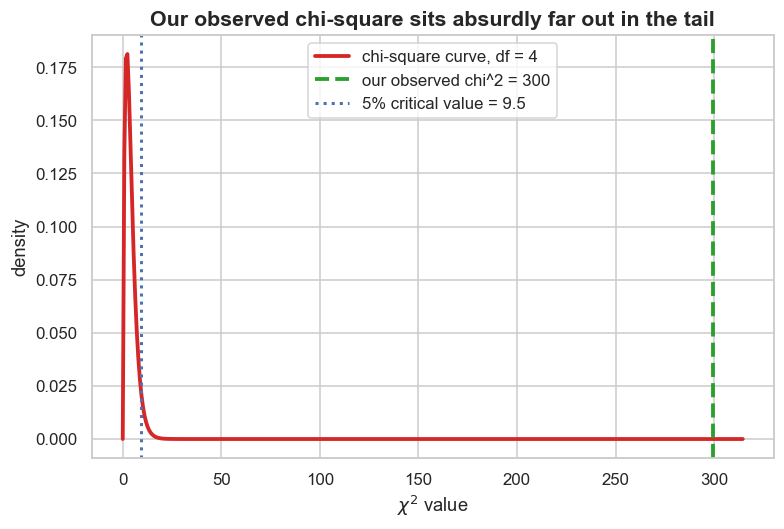

The whole curve is squeezed near 0; our 300 is off to the right, past everything.


In [8]:
fig, ax = plt.subplots()
xs = np.linspace(0, max(ind_stat * 1.05, 20), 400)
ax.plot(xs, stats.chi2.pdf(xs, df_ind), color='#d62728', lw=2.5,
        label=f'chi-square curve, df = {df_ind}')
ax.axvline(ind_stat, color='#2ca02c', lw=2.5, ls='--',
           label=f'our observed chi^2 = {ind_stat:.0f}')
# Mark the usual 0.05 critical value so the scale is clear.
crit = stats.chi2.ppf(0.95, df_ind)
ax.axvline(crit, color='#4c72b0', lw=2, ls=':', label=f'5% critical value = {crit:.1f}')
ax.set_xlabel('$\\chi^2$ value'); ax.set_ylabel('density')
ax.set_title('Our observed chi-square sits absurdly far out in the tail')
ax.legend(); plt.show()
print(f'The whole curve is squeezed near 0; our {ind_stat:.0f} is off to the right, past everything.')

The reference curve is bunched up against the left edge — almost all of its area sits below the blue 5%
critical line of about 9.5. Our observed value (green) is so far to the right it's nearly off the chart.
The area beyond it — the **p-value** — is what we compute now, and it is essentially zero.

### The one-liner: `scipy.stats.chi2_contingency`

In practice you don't grind out expected counts by hand. `chi2_contingency` takes the raw table and
returns the statistic, the p-value, the df, and the expected counts all at once. (We pass
`correction=False` to match our by-hand formula exactly.)

In [9]:
chi2_val, p_value, dof, expected_scipy = stats.chi2_contingency(contingency, correction=False)
print('--- Test of independence: Species vs Island ---')
print(f'chi^2   = {chi2_val:.1f}   (our hand value was {ind_stat:.1f})')
print(f'df      = {dof}')
print(f'p-value = {p_value:.2e}')
print('\nExpected counts from scipy (match ours):')
print(pd.DataFrame(expected_scipy.round(1), index=contingency.index, columns=contingency.columns))
print('\nVerdict: p is about 1e-63 -> reject independence, overwhelmingly.')
print('Species and island are about as far from independent as a table can be.')

--- Test of independence: Species vs Island ---
chi^2   = 299.6   (our hand value was 299.6)
df      = 4
p-value = 1.35e-63

Expected counts from scipy (match ours):
island     Biscoe  Dream  Torgersen
species                            
Adelie       74.2   54.8       23.0
Chinstrap    33.2   24.5       10.3
Gentoo       60.6   44.7       18.7

Verdict: p is about 1e-63 -> reject independence, overwhelmingly.
Species and island are about as far from independent as a table can be.


A p-value of roughly $1.4\times10^{-63}$ is not "small" in any everyday sense — it is a 1 followed by 63
zeros in the denominator. It says: *if* species and island were truly unrelated, a table this lopsided
would essentially never appear, not once in the lifetime of the universe of resampling. We reject
independence without a flicker of doubt.

### Confirm the expected-counts $\ge 5$ condition

The theoretical chi-square curve is an *approximation* that needs each **expected** cell to be about **5
or more**. It's a fair question here, since several *observed* cells are 0 — but the rule is about the
**expected** counts, and those are never zero. Let's check the smallest one.

In [10]:
min_expected = expected.min()
print('Smallest EXPECTED cell count:', round(min_expected, 2))
print('All expected counts:')
print(expected_df)
print(f'\nMinimum is {min_expected:.1f}, comfortably >= 5 -> the chi-square approximation is valid here.')
print('(Note: the >= 5 rule is about EXPECTED counts, not the observed zeros.)')

Smallest EXPECTED cell count: 10.28
All expected counts:
island     Biscoe  Dream  Torgersen
species                            
Adelie       74.2   54.8       23.0
Chinstrap    33.2   24.5       10.3
Gentoo       60.6   44.7       18.7

Minimum is 10.3, comfortably >= 5 -> the chi-square approximation is valid here.
(Note: the >= 5 rule is about EXPECTED counts, not the observed zeros.)


## 5) Titanic vs penguins — a tale of two extremes

This is the lesson's punchline. The chi-square statistic is one thing — **the total squared gap between
what we SEE and what INDEPENDENCE would predict** — but the *size* of that gap can live anywhere on a
spectrum:

| | core lesson (Titanic) | this lesson (penguins) |
|---|---|---|
| table | sex × survival (2×2) | species × island (3×3) |
| relationship | clear but **moderate** | **near-total** |
| does one pin down the other? | shifts the odds | can make it **certain / impossible** |
| structural zeros? | none | **three** (a species absent from an island) |
| observed $\chi^2$ | about 261 | about **300** |
| p-value | tiny | astronomically tiny ($\sim10^{-63}$) |

On the Titanic, being female *raised* your survival odds a lot, but plenty of women died and plenty of
men lived — independence was a strawman worth knocking down, and the gaps between observed and expected
were large but finite. Here, a Chinstrap **never** lives on Biscoe; the observed count is a hard zero
where independence insists on dozens. A structural near-impossibility like that is the extreme that
**pegs the meter**: it forces the widest possible $(O-E)$ gaps, which is why this $\chi^2$ is so large
and the p-value so vanishingly small. Chi-square didn't change its arithmetic — the *world* it measured
is simply far more lopsided.

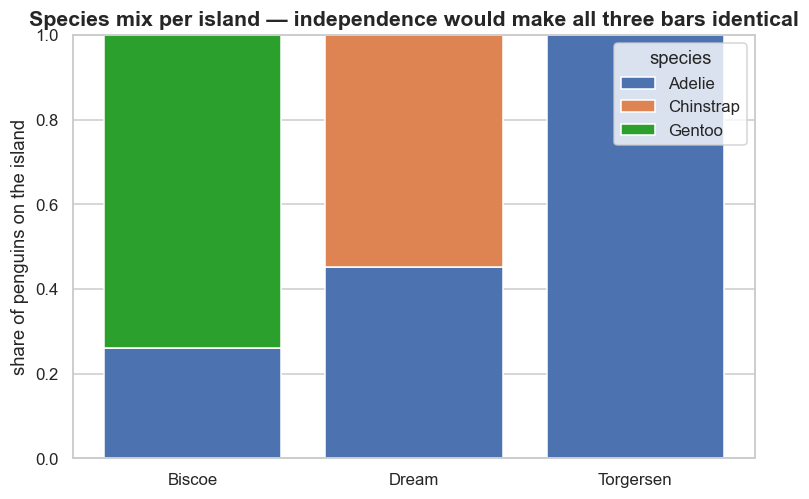

Under independence every bar would have the SAME coloured split.
Instead two islands are a single solid colour -> the association is near-total.


In [11]:
# Make the contrast tangible: how does each ISLAND split across species?
prop = (contingency / contingency.sum(axis=0)).T   # columns -> rows so islands are the bars
fig, ax = plt.subplots()
bottom = np.zeros(len(prop))
colors = {'Adelie': '#4c72b0', 'Chinstrap': '#dd8452', 'Gentoo': '#2ca02c'}
for sp in contingency.index:
    ax.bar(prop.index, prop[sp].to_numpy(), bottom=bottom,
           color=colors.get(sp, '#9aa7c7'), label=sp)
    bottom += prop[sp].to_numpy()
ax.set_ylabel('share of penguins on the island')
ax.set_title('Species mix per island — independence would make all three bars identical')
ax.legend(title='species'); plt.show()
print('Under independence every bar would have the SAME coloured split.')
print('Instead two islands are a single solid colour -> the association is near-total.')

If species and island were independent, all three stacked bars would show the **same** colour split (the
overall species mix). Instead, two of the three islands are a **single solid colour** — one species and
nothing else. That visual "all-or-nothing" is precisely what a $\chi^2$ of 300 is reporting in a number.

## 6) A goodness-of-fit aside — are the three species equally common?

The core lesson also showed chi-square's *other* flavour, **goodness-of-fit (GOF)**, which checks a
**single** categorical variable against a claimed distribution (df = categories − 1). Let's mirror it
quickly: are the three species present in **equal 1:1:1 proportions**? If so, with $N$ penguins we'd
expect about $N/3$ of each.

In [12]:
species_counts = pen['species'].value_counts().sort_index()
observed_sp = species_counts.to_numpy()
n_sp = observed_sp.sum()
expected_equal = np.full(3, n_sp / 3)   # the "equal thirds" claim

gof = pd.DataFrame({
    'species': species_counts.index,
    'observed': observed_sp,
    'expected (equal)': expected_equal.round(1),
    'O - E': (observed_sp - expected_equal).round(1),
})
print(gof.to_string(index=False))

chi2_gof, p_gof = stats.chisquare(f_obs=observed_sp, f_exp=expected_equal)
df_gof = len(observed_sp) - 1
print(f'\nGOF chi^2 = {chi2_gof:.1f}   df = {df_gof}   p-value = {p_gof:.2e}')
print('p is essentially 0 -> reject "equal thirds": the species are NOT equally common.')
print('(Adelie is the most numerous, Chinstrap the rarest.)')

  species  observed  expected (equal)  O - E
   Adelie       152             114.7   37.3
Chinstrap        68             114.7  -46.7
   Gentoo       124             114.7    9.3

GOF chi^2 = 31.9   df = 2   p-value = 1.18e-07
p is essentially 0 -> reject "equal thirds": the species are NOT equally common.
(Adelie is the most numerous, Chinstrap the rarest.)


A $\chi^2$ of about **32** on df = 2 gives a p-value near $10^{-7}$: the species are clearly **not** in
equal proportions (152 Adelie vs only 68 Chinstrap is too lopsided for chance). Note this is a much
*milder* rejection than the independence test's $\chi^2 \approx 300$ — a reminder that chi-square reports
*how* surprising, not merely *whether*.

## Now you try

Predict first, then change a number and re-run:

1. **Drop the lopsided species.** Remove Gentoo and Chinstrap so only **Adelie** is left, which lives on
   all three islands:

       adelie = pen[pen['species'] == 'Adelie']
       tab = pd.crosstab(adelie['island'], adelie['species'])
       # ... a one-column table can't test independence — so instead try Adelie's
       # ISLAND counts as a goodness-of-fit against equal thirds:
       isl = adelie['island'].value_counts().sort_index().to_numpy()
       print(stats.chisquare(isl, np.full(3, isl.sum() / 3)))

   Is Adelie spread evenly across its three islands, or does it favour one?

2. **A genuinely weak link.** Make a 2×2 table of two columns you'd expect to be *nearly* independent —
   for instance penguin **sex** vs a coin-flip you add yourself:

       p2 = pen.dropna(subset=['sex']).copy()
       rng = np.random.default_rng(0)
       p2['coin'] = rng.integers(0, 2, size=len(p2))
       print(stats.chi2_contingency(pd.crosstab(p2['sex'], p2['coin']), correction=False)[:3])

   The p-value should be **large** (no real link). Contrast that gentle result with this lesson's 300.

3. **Re-examine the $\ge 5$ rule.** In section 4, which *expected* cell is smallest, and why is it fine
   even though three *observed* cells are 0? Re-read why the rule is about expected, not observed, counts.

4. **Different claimed mix for GOF.** In section 6, replace `expected_equal` with a claim like 45% / 20% /
   35% of the total. Does the data fit *that* better or worse than equal thirds?

## What you learned

- The **chi-square test of independence** uses the exact same recipe everywhere: observed counts $O$,
  expected counts $E = (\text{row total}\times\text{column total})/N$ under independence, the statistic
  $\chi^2 = \sum (O-E)^2/E$, df $= (\text{rows}-1)(\text{columns}-1)$, and a p-value from the chi-square curve.
- For penguin **species vs island** the statistic was $\chi^2 \approx 300$ on **df = 4** with a p-value of
  about $1.4\times10^{-63}$ — an **overwhelming** association. `scipy.stats.chi2_contingency` reproduced the
  by-hand arithmetic exactly.
- The table has **structural zeros** (Chinstrap only on Dream, Gentoo only on Biscoe, Adelie on all three).
  Independence's formula never predicts zero, so it expected dozens of penguins in cells the world left
  empty — and **those gaps are exactly what inflated** $\chi^2$.
- The expected-counts **$\ge 5$** condition (smallest expected $\approx 10$) holds, so the test is valid —
  the rule is about **expected** counts, not the observed zeros.
- **The contrast:** on the Titanic the association was clear but **moderate** (independence worth testing);
  here it is **near-total** — knowing the island can make a species certain or impossible. A structural
  near-impossibility is the extreme that **pegs the meter**, producing an astronomically large $\chi^2$ and
  an essentially-zero p-value.
- A quick **goodness-of-fit** aside ($\chi^2 \approx 32$, df = 2, p $\approx 10^{-7}$) rejected "the three
  species are equally common" — a milder rejection that shows chi-square measures *how* surprising, not just
  *whether*.

---

**↩ Back to the lesson:** [Lesson 17: Chi-square: goodness-of-fit & independence](17-chi-square.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](17-chi-square~the-code.ipynb)